In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data/clean/application_train_clean.csv')
print(df.shape)

(307507, 79)


In [3]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles : {len(cat_cols)}")
print(cat_cols)

Colonnes catégorielles : 12
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [4]:
df.groupby('CODE_GENDER')['TARGET'].mean()


CODE_GENDER
F    0.069993
M    0.101419
Name: TARGET, dtype: float64

In [5]:
df.groupby('WEEKDAY_APPR_PROCESS_START')['TARGET'].mean()

WEEKDAY_APPR_PROCESS_START
FRIDAY       0.081473
MONDAY       0.077572
SATURDAY     0.078873
SUNDAY       0.079291
THURSDAY     0.081004
TUESDAY      0.083506
WEDNESDAY    0.081604
Name: TARGET, dtype: float64

minimal variation - dropping columns

In [9]:
for col in cat_cols:
    print(df.groupby(col)['TARGET'].mean().sort_values(ascending=False))

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054791
Name: TARGET, dtype: float64
CODE_GENDER
M    0.101419
F    0.069993
Name: TARGET, dtype: float64
FLAG_OWN_CAR
N    0.085003
Y    0.072439
Name: TARGET, dtype: float64
FLAG_OWN_REALTY
N    0.083249
Y    0.079617
Name: TARGET, dtype: float64
NAME_TYPE_SUITE
Other_B            0.098305
Other_A            0.087760
Group of people    0.084871
Unaccompanied      0.081831
Spouse, partner    0.078716
Family             0.074948
Children           0.073768
Unknown            0.054180
Name: TARGET, dtype: float64
NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095887
Commercial associate    0.074844
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64
NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089400
I

In [10]:
print(df['NAME_INCOME_TYPE'].value_counts())

NAME_INCOME_TYPE
Working                 158771
Commercial associate     71616
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df.shape)

(307507, 180)


Train/test splitting

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"Default rate train : {y_train.mean():.3f}")
print(f"Default rate test : {y_test.mean():.3f}")

Train : (246005, 178)
Test : (61502, 178)
Default rate train : 0.081
Default rate test : 0.081


In [22]:
import os
os.makedirs('data/clean', exist_ok=True)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

X_train_df.to_csv('data/clean/X_train.csv', index=False)
X_test_df.to_csv('data/clean/X_test.csv', index=False)
y_train.to_csv('data/clean/y_train.csv', index=False)
y_test.to_csv('data/clean/y_test.csv', index=False)

print(f"X_train : {X_train_df.shape}")
print(f"X_test : {X_test_df.shape}")

X_train : (246005, 178)
X_test : (61502, 178)


We calc scale_pos_weight this way to give more weight to delinquincy rows than non delinquincy to equilibrate the tree. 

In [15]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.1f}")

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=1
)

model.fit(X_train, y_train)
print("Modèle entraîné ✓")

scale_pos_weight : 11.4
Modèle entraîné ✓


In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

print(f"AUC-ROC : {auc:.4f}")
print(f"Gini : {gini:.4f}")

AUC-ROC : 0.7644
Gini : 0.5288


In [17]:
from scipy.stats import ks_2samp

scores_default = y_pred_proba[y_test == 1]
scores_no_default = y_pred_proba[y_test == 0]

ks_stat, _ = ks_2samp(scores_default, scores_no_default)
print(f"KS Statistic : {ks_stat:.4f}")

KS Statistic : 0.3929


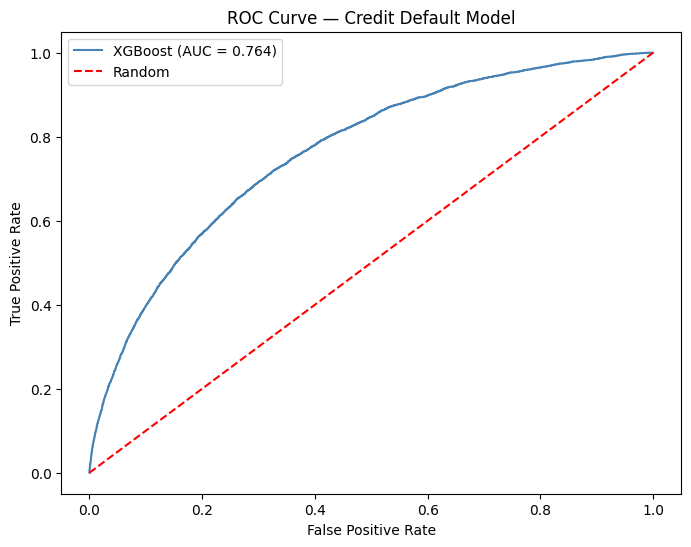

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Default Model')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

Optimization with optuna

In [19]:
import optuna
import mlflow
from sklearn.metrics import roc_auc_score

mlflow.set_experiment("credit-default-model")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'auc'
    }
    
    with mlflow.start_run(nested=True):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred)
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc)
        return auc

with mlflow.start_run(run_name="optuna_search"):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)

print(f"Meilleur AUC : {study.best_value:.4f}")
print(f"Meilleurs params : {study.best_params}")

2026/03/27 13:11:29 INFO mlflow.tracking.fluent: Experiment with name 'credit-default-model' does not exist. Creating a new experiment.
[I 2026-03-27 13:11:29,230] A new study created in memory with name: no-name-f964ebc1-fef9-4928-b375-0667e2026ed2
[I 2026-03-27 13:11:34,075] Trial 0 finished with value: 0.7595236788584705 and parameters: {'n_estimators': 437, 'max_depth': 5, 'learning_rate': 0.012449295731451216, 'subsample': 0.9057842549170814, 'colsample_bytree': 0.904515932570676}. Best is trial 0 with value: 0.7595236788584705.
[I 2026-03-27 13:11:36,813] Trial 1 finished with value: 0.7594736639327229 and parameters: {'n_estimators': 245, 'max_depth': 4, 'learning_rate': 0.030256112145595176, 'subsample': 0.9347571360940836, 'colsample_bytree': 0.6921186253947094}. Best is trial 0 with value: 0.7595236788584705.
[I 2026-03-27 13:11:39,775] Trial 2 finished with value: 0.7700025565875895 and parameters: {'n_estimators': 347, 'max_depth': 4, 'learning_rate': 0.13190875382957365, '

Meilleur AUC : 0.7717
Meilleurs params : {'n_estimators': 494, 'max_depth': 4, 'learning_rate': 0.0861947736655223, 'subsample': 0.786130402310454, 'colsample_bytree': 0.9324828520998192}


In [20]:
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['random_state'] = 42
best_params['eval_metric'] = 'auc'

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict_proba(X_test)[:, 1]
auc_final = roc_auc_score(y_test, y_pred_final)
gini_final = 2 * auc_final - 1
ks_final, _ = ks_2samp(y_pred_final[y_test == 1], y_pred_final[y_test == 0])

print(f"AUC-ROC : {auc_final:.4f}")
print(f"Gini    : {gini_final:.4f}")
print(f"KS      : {ks_final:.4f}")

AUC-ROC : 0.7717
Gini    : 0.5434
KS      : 0.4026


In [21]:
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Modèle sauvegardé ✓")

Modèle sauvegardé ✓


## SHAP